# Derivative Free Optimization

There are many different derivative-free optimization (DFO) methods.
Some are designed to be global optimizers: they seek the global minimum.
However, other DFO methods only seek a local minimizer.

In this section, we'll look at some heuristic methods, which include:

* Genetic algorithms (or evolutionary algorithms) (GA or EA)
* Particle swarm optimization (PSO)

We'll also consider DFO algorithms that are not heuristic including:

* Coordinate and pattern search methods
* Model-based DFO

There are numerous papers in the literature with different heuristic optimization algorithms.
Other methods in this class include:

* Simulated annealing
* Tabu search
* Bee colony/ant colony/bacterial foraging, etc.

These methods can be useful since they can handle non-smooth functions, mixed-integer variables and categorical variables.
Many people focus on the fact that these methods can find global solutions.
But in my opinion, this is not surprising or a key selling point.
This method also finds a global solution eventually:
  
1. Pick $x_{0}$ and set $f_{0} \leftarrow f(x_{0})$
2. Pick $x$ randomly
3. If $f(x) < f_{0}$ Set $x_{0} \leftarrow x$, $f_{0} \leftarrow f(x)$
4. Goto step 2

## Terminology

* *Global convergence*: Convergence to a local minimizer/critical point from any starting point - this is provable for many gradient-based methods.
* *Global optimizer*: An optimizer which is designed to try to find the global minimum 
* *Convergence*: Does the optimization algorithm converge to a local or global optimum: Provable for many DFO methods, but this is the easy part
* *Rate of convergence*: How quickly does the optimization algorithm converge when its near a local/global solution
  
We will look at some heuristic/metaheuristic optimization methods, but focus some attention on more-rigorous DFO methods:

* Model-based DFO, good for smooth optimization 
* Pattern search, mesh-adaptive direct (MADS) search

We'll look exclusively at derivative-free methods for optimization with bound constraints

\begin{equation*}
\begin{aligned}
\min_{x} \qquad & f(x) \\
\text{such that} \qquad & l \le x \le u
\end{aligned}
\end{equation*}

General constraints can be added by either:

1. Using penalty methods
2. Using augmented Lagrangian methods
3. Rejecting points that are infeasible (suitable for some types of algorithms)

## Genetic Optimization Algorithms

Inspired by evolutionary processes in nature. These algorithms generally consist of a number of steps:

1. Initialization of the population
2. *Selection*
3. *Crossover* Reproduction/propagation of genetic traits 
4. *Mutation* Injects a random variation into the population
5. Fitness evaluation
6. Replacement

These terms are in common usage.

The basic approach to genetic algorithms is as follows:
  
1. Create a set of samples in the design space, referred to as a population.
2. Apply some selection criteria to create a pool of design points to merge.
3. Apply a crossover operation to generate new data points, designed so that the newly generated samples are likely to retain good performing points. 
4. Add randomness to the sample set.

The advantages of genetic algorithms are:

* The variables are encoded so that they can easily accommodate continuous, integer and discrete design variables
* The population can be distributed so that it tends not to get stuck in local minima 
* It can handle noisy functions or functions that are not smooth
* It can be used for multi-objective optimization
* The implementation is straightforward 

The disadvantages of genetic algorithms are:

* They can be expensive compared to gradient-based methods
* Their computational cost scales strongly with the number of design variables

Genetic algorithms are better than brute force, but fundamentally rely on the stochastic mechanism to be classified as a global optimizer.
Due to stochastic nature, performance of the GA must be measured using a statistically significant number of optimization runs.

### Generic Genetic Algorithm Components

#### Encoding design points

Some GAs use real-valued design variables directly. 
However, many GAs use an encoding sequence to store the design variable values.
In this approach, all the design variables become discrete.

We can represent a finite number of values using $m$ bits.
Real numbers between the lower value $l$ and the upper value $u$ can be found as follows:

\begin{equation*}
x = l + (u - l)\left[ \sum_{i=0}^{n} b_{i} 2^{-k-1} \right]
\end{equation*}

Here $b$ is a binary vector such that $b_{i} \in \{0, 1\}^{n}$. For instance, $b = \begin{bmatrix} 0 & 1 & 1 & 0 & 1 \end{bmatrix}$.

Binary values can be encoded and decoded using the following functions:

```python
def decode(b, low=0.0, high=1.0):
    val = 0.0
    for b0 in b[::-1]:
        val = 0.5 * (val + b0)
    return low + (high - low) * val
```

```python
def encode(val, n=10, low=0.0, high=1.0):
    v = (val - low)/(high - low)
    b = []
    for i in range(n):
        if v >= 0.5:
            b.append(1)
            v = (v - 0.5)/0.5
        else:
            b.append(0)
            v = v/0.5
    return b
```

Note that there can be information loss

```python
>>> decode(encode(0.5))
0.5
>>> decode(encode(0.65))
0.6494140625
>>> decode(encode(0.15))
0.1494140625
```

In practice, it's better to use *Gray code* to encode the design variables. https://en.wikipedia.org/wiki/Gray_code.

<!-- 
```python
def bin_to_gray(b):
    g = []
    if b[0] == 0:
        g.append(0)
    else:
        g.append(1)
    for i in range(len(b) - 1):
        if b[i] == b[i+1]:
            g.append(1)
        else:
            g.append(0)
    return g
```


```python
def gray_to_bin(g):
    b = []
    if g[0] == 0:
        b.append(0)
    else:
        b.append(1)
```
-->

#### Initialization

The goal of the initialization procedure is to obtain a sample set $\{ x_{k} \}$ satisfying $l \le x_{k} \le u$.

As a rule of thumb, the population should be 15 to 20 times the number of design variables.
Often, the initial encoding sequence is $b_{i}$ generated randomly

#### Selection

Determine a mating pool, by either:

* Selecting the mates randomly
* Select based on fitness: better members reproduce more than others the next population through a cross over operation

#### Mutation

* Add randomness to the population

## Particle Swarm Optimization

Particle Swarm Optimization (PSO) is a a stochastic, population-based optimization algorithm.
Originally developed by J. Kennedy and R. Eberhart, a social-psychologist and an electrical engineer, respectively.
The method is motivated by the idea of *swarm intelligence*. The authors defined swarm intelligence as

> Swarm intelligence: Collective, intelligent behaviors emerge from a population of individuals interacting locally within their environment

In PSO methods, a number of particles move in the design space.
The particles are given dynamics that depend on:

1. An inertial effect 
2. The best point achieved by the individual particle at any iteration
3. The best point achieved by any particle on the last iteration

For each particle $n$:

\begin{equation*}
\begin{aligned}
x_{k+1}^{n} & = x_{k}^{n} + v_{k}^{n} \Delta t \\
v_{k}^{n}  & = w v_{k-1}^{n} + \frac{r_{1}}{\Delta t} (b^{n} - x_{k}^{n}) + \frac{r_{2}}{\Delta t}(p_{k} - x_{k}^{n})
\end{aligned}
\end{equation*}

Here the variables are defined such that

* $w$ is an inertial parameter
* $r_{1}$ is a random number on the interval $[0, c_{1}]$
* $r_{2}$ is a random number on the interval $[0, c_{2}]$
* $b^{n}$ is the best point for this particle, $f(b^{n}) = \min_{k} f(x_{k}^{n})$
* $p_{k}$ is the best point for this iteration, $f(p_{k}) = \min_{n} f(x_{k}^{n})$

![Particle swarm optimization](pso_diagram.png)

The PSO algorithm can be defined as follows:

1. Select (possibly randomly) a set of particles $\{x_{1}^{n}\}$, for $n = 1,\ldots,N$
2. Select randomly a set of particle velocities $\{v_{1}^{n}\}$ for $n = 1,\ldots,N$
3. Set $k = 1$
4. Compute $f(x_{k}^{n})$ for $n = 1,\ldots,N$
5. Update $b^{n}$ and $p_{k}$ using $f(b^{n}) = \min_{k} f(x_{k}^{n})$ and $f(p_{k}) = \min_{n} f(x_{k}^{n})$
6. Update the velocities using:

\begin{equation*}
v_{k}^{n}  = w v_{k-1}^{n} + \frac{r_{1}}{\Delta t} (b^{n} - x_{k}^{n}) + \frac{r_{2}}{\Delta t}(p_{k} - x_{k}^{n})
\end{equation*}

7. Update the particle positions: $x_{k+1}^{n} = x_{k}^{n} + v_{k}^{n}$
8. Set $k = k+1$ and go to step 4

## Coordinate and pattern search methods


### Coordinate search

* At each iteration, search along a new coordinate direction $e_{j}$ to approximately minimize $f(x_{k} + \alpha e_{j})$
* The sequence in which we choose $e_{j}$ is important
* Any arbitrary selections of the sequence $e_{j}$ will not necessarily converge
* The steepest descent direction $-\nabla f$ may become perpendicular to the coordinate search direction

The sequence $e_{1}, e_{2},\ldots,e_{n-1}, e_{n}, e_{n-1},\ldots, e_{2}, e_{1}, e_{2},\ldots$ can be shown to produce a convergent algorithm.
Convergence can be slow, especially for functions not well-aligned with the coordinate axes.

![Coordinate descent](coordinate_descent.png)

### Pattern search methods

* At each iteration perform a poll of all directions $p_{j} \in \mathcal{D}_{k}$, where $\mathcal{D}_{k}$ is a set of directions
* Search directions must be carefully chosen so that we ensure that at least one direction $p_{j} \in \mathcal{D}_{k}$ is a descent direction of $f(x)$
* It turns out that we need at least $n+1$ directions
* We can recover coordinate search by selecting $i$ and setting:

\begin{equation*}
\mathcal{D}_{k} = \{e_{i}, -e_{i}\}
\end{equation*}

* However, this choice does not satisfy the property $\kappa(\mathcal{D}) > 0$
* Another choice of $\mathcal{D}$ are the coordinate directions:
 
\begin{equation*}
\mathcal{D} = \{e_{1},e_{2},\ldots,e_{n},-e_1, -e_2,\ldots,-e_{n}\}
\end{equation*}

* Or the search directions:
 
\begin{equation*}
p_{i} = \frac{1}{2n}e - e_{i}, \qquad i = 1,\ldots,n \qquad p_{n} = \frac{1}{2n} e
\end{equation*}

#### Selecting the direction set $\mathcal{D}_{k}$

* Consider the angle between the negative gradient direction and a direction $p$:

\begin{equation*}
\cos \theta = \frac{-\nabla f^{T}p}{||\nabla f|| \; ||p||}
\end{equation*}
  
* Since $\nabla f$ may be any direction, we are interested in the worst case which can be written as:

\begin{equation*}
\kappa(\mathcal{D}) = \min_{v} \max_{p \in \mathcal{D}} \frac{v^{T}p}{||v|| \; ||p||} 
\end{equation*}

* We also must ensure that the length of the directions are bounded $\beta_{\min} \le ||p|| \le \beta_{\max}$
* If the directions are bounded and $\kappa(\mathcal{D}) > 0$, then at least one direction is a descent direction:

\begin{equation*}
- \nabla f^{T}p \ge \kappa(\mathcal{D}) ||\nabla f|| \; ||p|| \ge \beta_{\min} \kappa(\mathcal{D}) ||\nabla f||
\end{equation*}

#### Pattern search algorithm

1. Select contraction/expansion parameters $\theta$ and $\phi$
2. Select a convergence tolerance $\gamma_{tol}$
3. Pick $x_{1}$ and an initial step length $\gamma_{1} \ge \gamma_{tol}$ and an initial set of directions $\mathcal{D}_{1}$
4. Set $k = 1$
5. While $\gamma_{k} > \gamma_{tol}$
6. If $f(x_{k} + \gamma_{k}p_{j}) < f(x_{k}) - \rho(\gamma_{k})$ for some $p_{j} \in \mathcal{D}_{k}$
* Set $x_{k+1} = x_{k} + \gamma_{k} p_{j}$
* Set $\gamma_{k+1} = \phi \gamma_{k}$
7. Else
* Set $x_{k+1} = x_{k}$
* Set $\gamma_{k+1} = \theta \gamma_{k}$
8. Set $k = k + 1$ and go to step 5

* $\rho(t)$ is a function that satisfies $\lim_{t \rightarrow 0} \frac{\rho(t)}{t} = 0$
* $\rho(t) = \alpha t^{3/2}$ is a common choice

![Pattern search](pattern_search.png)

## Model-based DFO

* If the objective is smooth, we can approximate it using a quadratic model
* This is similar to gradient-based methods that build  quadratic models using gradient/Hessian information
* At each iteration, we can form $m_{k}(p)$ centered about the point $x_{k}$ as follows:
 
\begin{equation*}
m_{k}(p) = c + g^{T}p + \frac{1}{2}p^{T} B p
\end{equation*}

* However $\nabla f$ is unavailable, so we have to interpolate
* Assume that we can sample $f(x)$ at the points $\mathcal{Y} = \{y_{1},\ldots,y_{q}\}$ then $m_{k}(\cdot)$ will satisfy the interpolation conditions:

\begin{equation*}
m_{k}(y_{j} - x_{k}) = f(y_{j}), \qquad j = 1,\ldots,q
\end{equation*}
  
* We will need $q = \frac{1}{2}(n + 1)(n+2)$ points to fully determine $c$, $g$ and $B$ 
* Then we can use a trust-region framework and solve:
 
\begin{equation*}
\min_{p} m_{k}(p) \qquad ||p|| \le \Delta_{k}
\end{equation*}

* How we choose $\mathcal{Y}_{k}$ is important - note that it is iteration-dependent
* We cannot choose $\mathcal{Y}_{k}$ arbitrarily - for instance if all the points in $\mathcal{Y}_{k}$ lie on a line then we cannot perform interpolation
* As the interpolation gets closer to a degeneracy like this, the poorer our interpolation will be
* We can monitor how well-poised the interpolation set is by examining a shifted and scaled variant of the interpolation set $\hat{\mathcal{Y}}$
* Once we have a full interpolation set, we may have to determine which $y_{j} \in \mathcal{Y}_{k}$ to discard so that we only have $q$ vectors

![Model-based DFO sample set](model_based_dfo_set.png)

### Improving the geometry of the interpolation set

* Model-based DFO algorithms often implement a geometry-improvement step to ensure that $\mathcal{Y}_{k}$ is well chosen
* These algorithms remove a point $y_{-} \in \mathcal{Y}_{k}$ and add a point $y_{+}$ such that $\mathcal{Y}_{k+1} = y_{+} \cup \left\{\mathcal{Y}_{k} \setminus y_{-} \right\}$
* These algorithms are often based on the Lagrange polynomials $\ell_{i}(x; \mathcal{Y})$ for $i = 1,\ldots,q$ defined such that:

\begin{equation*}
\ell_{i}(y_{j}; \mathcal{Y}) = \delta_{ij}
\end{equation*}
  
* If we know the point we want to add, $y_{+}$ we may choose to remove point $y_{-} = y_{i_{\max}}$ chosen such that:

\begin{equation*}
i_{\max} = \arg \max_{i} |\ell_{i}(y_{+}; \mathcal{Y}_{k})|
\end{equation*}

* In other words, remove the point corresponding to the Lagrange polynomial with the largest magnitude

### Linear interpolation models

* Consider first the case of linear interpolation with $q = n+1$:
 
\begin{equation*}
m_{k}(p) = f(x_{k}) + g^{T}p
\end{equation*}

* For the interpolant to match at the points $y_{j}$ we must have:

\begin{equation*}
f(x_{k}) + g^{T}(y_{j} - x_{k}) = f(y_{j}) \qquad \implies \qquad  f(y_{j}) - f(x_{k}) = (y_{j} - x_{k})^{T}g
\end{equation*}

### Quadratic interpolation models

* A quadratic model can be defined as follows:
 
\begin{equation*}
m_{k}(p) = f(x_{k}) + g^{T}p + \frac{1}{2} p^{T} B p
\end{equation*}

* This leads to the interpolation conditions:
 
\begin{equation*}
f(y_{j}) = f(x_{k}) + g^{T}(y_{j} - x_{k}) + \frac{1}{2} (y_{j} - x_{k})^{T} B (y_{j} - x_{k})
\end{equation*}

* Writing $s_{j} = y_{j} - x_{k}$, we can rewrite this condition as:
 
\begin{equation*}
f(y_{j}) = f(x_{k}) + g^{T}s_{j} + \frac{1}{2} s_{j}^{T} B s_{j}
\end{equation*}

* We can write this as a linear system if we introduce the following notation for converting a matrix into a vector: $\text{vec}(A) = a \in \mathbb{R}^{n(+1)/2}$

\begin{equation*}
\text{vec}(A)_{i + j(j-1)/2} = \left\{ \begin{array}{ll} 
\sqrt{2} A_{ij} \qquad & i \ne j \\
A_{ii} \qquad          & i = j
\end{array} \right.
\end{equation*}

\begin{equation*}
\text{vec}\begin{bmatrix} 
a_{11} & a_{12} & a_{13} \\
a_{12} & a_{22} & a_{23} \\
a_{13} & a_{23} & a_{33} 
\end{bmatrix} 
= \begin{bmatrix} 
a_{11} & \sqrt{2} a_{12} & a_{22} & 
\sqrt{2} a_{13} & \sqrt{2} a_{23} & a_{33}
\end{bmatrix}^{T}
\end{equation*}

* Using this notation we can find the following:
 
\begin{equation*}
s_{j}^{T} g + \frac{1}{2} \left[ \text{vec}(s_{j} s_{j}^{T})\right]^{T} \text{vec}(B) = f(x_{k}) - f(y_{j})
\end{equation*}

### Minimum change update model

* If we use a full quadratic model with interpolation we need to evaluate $(n+1)(n+2)/2$ points before we start optimization
* This can be costly when $n$ is large
* Idea: Form an approximate quadratic model from $\mathcal{O}(n)$ points and take up the additional degrees of freedom using least-Frobenius norm updates
* In practice, we can use $q = 2n +1$ points
* This idea is similar to the BFGS/quasi-Newton updating schemes

* Given model the $m_{k}(p) = c_{k} + p^{T}g_{k} + \frac{1}{2} p^{T}B_{k} p$ we want to find the update to $c_{k+1}$, $g_{k+1}$ and $B_{k+1}$ that solves the following minimum change problem:

\begin{equation*}
\begin{aligned}
\min_{c_{k+1}, g,_{k+1} B_{k+1}} \qquad & ||B_{k+1} - B_{k}||_{F} \\
\text{such that} \qquad & c_{k+1} + g_{k+1}^{T}(y_{j} - x_{k}) + \\
& \frac{1}{2} (y_{j} - x_{k})^{T}B_{k+1} (y_{j} - x_{k}) = f(y_{j})
\end{aligned}
\end{equation*}

* Setting $s_{j} = y_{j} - x_{k}$ and defining $c = c_{k+1} - c_{k}$, $g = g_{k+1} - g_{k}$ and $B = B_{k+1} - B_{k}$, we can define the problem:

\begin{equation*}
\begin{aligned}
\min_{c, g, B} \qquad & || B ||_{F} \\
\text{such that} \qquad & c + g^{T}s_{j} + \frac{1}{2}s_{j}^{T} B s_{j} 
= d_{j} = f(y_{j}) - m_{k}(y_{j} - x_{k})
\end{aligned}
\end{equation*}

* The Lagrangian for this problem can be written as follows:
 
\begin{equation*}
\mathcal{L}(c, g, B) = \frac{1}{4} \sum_{ij} B_{ij}^2 - 
\sum_{j=1}^{q} \lambda_{j}\left( c + g^{T}s_{j} + \frac{1}{2} s_{j}^{T}B s_{j} - d_{j} \right)
\end{equation*}

* Differentiating with respect to $c$, $g$, and $B$, respectively yields:

\begin{equation*}
\sum_{j=1}^{q} \lambda_{j} = 0 \qquad  
\sum_{j=1}^{q} \lambda_{j} s_{j} = 0 \qquad
B = \sum_{j=1}^{q} \lambda_{j} s_{j} s_{j}^{T}
\end{equation*}

* We can substitute this back into the expression for the equality constraints

\begin{equation*}
c + g^{T}s_{i} + \frac{1}{2} \sum_{j=1}^{q} \lambda_{j} (s_{i}^{T}s_{j})^2 = d_{i}
\end{equation*}

* Writing $A_{ij} = \frac{1}{2} (s_{i}^{T}s_{j})^2$, $A \in \mathbb{R}^{q\times q}$ and $S = \left[ s_{1}, s_{2}, s_{3} \ldots \right] \in \mathbb{R}^{n \times q}$ we obtain the following linear system:

\begin{equation*}
\begin{bmatrix} 
A    & e & S^{T} \\
e^{T} & 0 & 0 \\
S    & 0 & 0 \\
\end{bmatrix}
\begin{bmatrix}
\lambda \\ c \\ g \\
\end{bmatrix} = 
\begin{bmatrix}
d \\ 0 \\ 0 \\
\end{bmatrix} 
\end{equation*}

### The Lagrange polynomials

* We can derive a type of Lagrange polynomial that take the form:

\begin{equation*}
m_{k+1}(p) - m_{k}(p) = \sum_{j=0}^{q-1} d_{j} \ell_{j}(p)
\end{equation*}

* Recall $d_j = f(y_{j}) - m_{k}(y_{j} - x_{k})$
* The coefficients of these polynomials can be found as follows:
 
\begin{equation*}
\begin{bmatrix}
A    & e & S^{T} \\
e^{T} & 0 & 0 \\
S    & 0 & 0 \\
\end{bmatrix}
\begin{bmatrix}
\Lambda \\ \eta \\ \Gamma
\end{bmatrix} = 
\begin{bmatrix}
I \\ 0 \\ 0 \\
\end{bmatrix} 
\end{equation*}

* Finally, the Lagrange polynomials take the following form:
 
\begin{equation*}
\ell_{i}(p) = \eta_{i} + \Gamma_{i}^{T}p + \sum_{j=1}^{q} \frac{1}{2} \Lambda_{ij}(s_{j}^{T} p)^2 
\end{equation*}

### Changing the base point $x_{k}$

* After solving the optimization problem, we obtain the new model function:

\begin{equation*}
m_{k+1}(p) = c_{k+1} + p^{T} g_{k+1} + \frac{1}{2}p^{T}B_{k+1} p
\end{equation*}

* Where $c_{k+1} = c + c_{k}$, $g_{k+1} = g + g_{k}$ and $B_{k+1} = B + B_{k}$f
* Note that the model $m_{k+1}$ is centered about $x_{k+1}$
* After the trust region problem, we obtain the new point $x_{k+1}$, which we may want to use as the model base point for future iterations, in which case we need to update the model again:

\begin{equation*}
\begin{aligned}
c & \leftarrow c + g^{T}(x_{k+1} - x_{k}) + \frac{1}{2} (x_{k+1} - x_{k})^{T} B (x_{k+1} - x_{k}) \\
g & \leftarrow g + B (x_{k+1} - x_{k}) \\
\end{aligned}
\end{equation*}

### DFO algorithm

* Simple model-based DFO algorithm, but provably convergent

1. Given $x_{1}$, compute the $2n+1$ initial points $y_{j} \in \mathcal{Y}_1$} 
2. Set $y_{1} = x_{1}$, $y_{2k} = x_{1} + \Delta e_{k}$, and $y_{2k+1} = x_{1} - \Delta e_{k}$
3. Evaluate $f(y_{j})$ for all $y_{j} \in \mathcal{Y}_{1}$ and compute $c_{1}$, $g_{1}$ and $B_{1}$
4. Convergence check: $||g_{k}|| \le \epsilon_{tol}$ \emph{and} $\Lambda_{\mathcal{Y}_{k}} \le \Lambda_{0}$, (apply model improvement)}
5. Compute $x^{*} = \arg \min m_{k}(p) \;\; ||p|| \le \Delta_{k}$
6. Compute $\rho_{k}$ and apply the trust region update to get $\Delta_{k+1}$
7. Add $x_{k+1}$ to the set $\mathcal{Y}_{k+1} = x_{k+1} \cup \{ \mathcal{Y}_{k} \setminus y_{-}\}$
8. If successful trust region step center the trust region about the new best point $x_{k+1}$
9. Else discard points $y_{j}$, $||y_{j} - y_{1}|| > \Delta_{k}$ and apply model improvement to achieve $\Lambda_{\mathcal{Y}_{k+1}} \le \Lambda_{0}$
10. Compute and apply the updates $c$, $g$ and $B$
11. Return to step 3

### Model error and the Lagrange polynomials

* There is a strong connection between model error and the Lagrange polynomials
* We can write the model $m(x)$ in terms of the Lagrange polynomials as follows:
   
\begin{equation*}
m(x) = \sum_{i=1}^{q} \ell_{i}(x) f(y_{i})
\end{equation*}

* For a straightforward bound, consider the case of quadratic interpolation when $f(x)$ has third derivatives that are continuous and bounded such that $|f'''| \le \beta$
* In the quadratic case, the interpolation error bound takes the following form

\begin{equation*}
|f(x) - m(x)| \le \frac{\beta}{6} \sum_{i=1}^{q} |\ell_{i}(x)| \; ||x - y_{i}||^3 \le q \frac{\beta}{6} \Lambda \Delta^{3} 
\end{equation*}

Here $\Lambda = \max_{i} \max_{x} |\ell_{i}(x)|$ and $\Delta = \max_{i} ||y_{i} - y_{1}||$. Note that large values of $\ell_{i}(x)$ lead to poor error estimates.

* How can we pick new points for $\mathcal{Y}$ that will improve the geometry of the interpolation set?
* First, we need a way to measure for the quality of a set of interpolation points
* In general, we can write a polynomial as:
 
\begin{equation*}
m(x) = \sum_{j=1}^{q} \alpha_{j} \phi_{j}(x)  
\end{equation*}

* We can determine $\alpha_{j}$ using a full interpolation scheme by evaluating $f(x)$ at $y_{j} \in \mathcal{Y}$:

\begin{equation*}
m(y_{j}) = \sum_{j=1}^{q} \alpha_{j} \phi_{j}(y_{j}) = f(y_{j})
\end{equation*}

* We can write this as a $q \times q$ system of linear equations for $\alpha$:
   
\begin{equation*}
M(\phi, \mathcal{Y}) \alpha = F(\mathcal{Y})
\end{equation*}

#### Example

* Consider, $n = 2$ and $d = 2$
* Therefore $q = \frac{1}{2}(n+1)(n+2)= 6$
* Consider the natural basis of polynomials:

\begin{equation*}
\phi(x) = \left\{ 1, x_1, x_2, x_1^2, x_1 x_2, x_{2}^2\right\}
\end{equation*}
  
\begin{equation*}
M(\phi, \mathcal{Y}) = 
\begin{bmatrix}
\phi_{1}(y_{1}) & \phi_{2}(y_{1}) & \phi_{3}(y_{1}) & \ldots & \phi_{6}(y_{1}) \\
\phi_{1}(y_{2}) & \phi_{2}(y_{2}) & \phi_{3}(y_{2}) & \ldots & \phi_{6}(y_{2}) \\
\vdots & \vdots & \vdots & \vdots & \vdots \\
\phi_{1}(y_{6}) & \phi_{2}(y_{6}) & \phi_{3}(y_{6}) & \ldots & \phi_{6}(y_{6}) \\
\end{bmatrix}
\end{equation*}

### Geometry improvement algorithms
  
* In general, the condition number of $M(\phi, \mathcal{Y})$ is not a good indicator of the quality of $\mathcal{Y}$
* We can scale the basis functions $\phi(x)$ to get arbitrarily poor condition numbers, without affecting the interpolation
* The classical measure of poisedness is based on the Lagrange polynomials such that $\ell_{i}(y_{j}) = \delta_{j}$ and the model can be written:

\begin{equation*}
m(x) = \sum_{i=1}^{q} \ell_{i}(x) f(y_{i})
\end{equation*}

* Note that this requires that $M(\phi, \mathcal{Y})$ be invertible 
* For any $x$ in the convex hull of $\mathcal{Y}$, and the 

\begin{equation*}
|m(x) - f(x)| \le \frac{q}{(d+1)!}G\Lambda_{\mathcal{Y}} \Delta^{d+1}
\end{equation*}

* Where $d$ is the degree of the polynomial, $G$ is a bound on the $d+1$ derivative of $f(x)$ in $x \in \mathcal{B}(\Delta)$

#### $\Lambda_{\mathcal{Y}}$-poised

* The constant $\Lambda_{\mathcal{Y}}$ is defined as:
  
\begin{equation*}
\Lambda_{\mathcal{Y}} = \max_{i} \max_{x \in \mathcal{B}(\Delta)} |\ell_{i}(x)|
\end{equation*}

* We will try and maintain good geometry of our points by bounding $\Lambda_{\mathcal{Y}}$ by adjusting the points in $\mathcal{Y}$
* We will refer to sets $\mathcal{Y}$ that have bounded $\Lambda_{\mathcal{Y}}$ as $\Lambda_{\mathcal{Y}}$-poised
* Large values of $\Lambda_{\mathcal{Y}}$ are bad and lead to nearly-dependent Lagrange polynomials
* When $q = (n +1)(n+2)/2$, we can write the Lagrange polynomials as the solution to the following system of equations:

\begin{equation*}
M^{T}(\phi, \mathcal{Y}) \ell(x) = \phi(x)
\end{equation*}

* We can use this to establish a bound on $||\ell(x)||_{\infty}$    
* In practice it is easier to work with a shifted and scaled version of the set:

\begin{equation*}
\hat{\mathcal{Y}} = \left\{ 0, \frac{y_2 - y_1}{\Delta}, 
\frac{y_3 - y_1}{\Delta},\ldots,\frac{y_q - y_1}{\Delta} \right\}
\end{equation*}

* Where $\Delta = \max_{y_{j} \in \mathcal{Y}} ||y_{j} - y_{1}||$
* This leads to the equivalent system of equations:
 
\begin{equation*}
\hat{M}^{T}(\phi, \hat{\mathcal{Y}}) \ell\left( x \right) = \phi \left(\frac{x - y_1}{\Delta}\right)
\end{equation*}

* Some model improvement algorithms work by bounding $||\hat{M}^{-1}||$
* These algorithms look like QR factorization or LU factorization
* The norm $||\hat{M}^{-1}||$ and the condition number $\kappa(\hat{M})$ are related since $||\hat{M}||$ is bounded

#### Model improvement algorithm based on Lagrange polynomials

* At certain points in the model-based DFO algorithm we will want to improve the quality of the interpolation set
* We will use an algorithm based on the Lagrange polynomials
* The algorithm requires an upper bound $\Lambda_{0}$ and proceeds as follows:
    
1. Compute $\Lambda_{\mathcal{Y}} = \max_{i} \max_{x \in \mathcal{B}} |\ell_{i}(x)|$
2. If $\Lambda_{\mathcal{Y}} \le \Lambda_{0}$, quit: we have a set of points poised for interpolation
3. Otherwise pick $j$ such that $\max_{x \in \mathcal{B}} |\ell_{j}(x)| > \Lambda_{0}$
4. Compute $y_{j}^{+} = \max_{x \in \mathcal{B}} |\ell_{j}(x)|$
5. Update the set, removing the old point, $\mathcal{Y} \leftarrow \{ \mathcal{Y} \setminus y_{j} \} \cup y_{j}^{+}$
6. Repeat until $\Lambda_{\mathcal{Y}} \le \Lambda_{0}$
 
* For computational efficiency, $\Lambda_{\mathcal{Y}}$ may be computed using an estimate/bound instead of computing the exact value of $\max_{i} \max_{x \in \mathcal{B}} |\ell_{i}(x)|$
* Step 3 may be replaced with a simple heuristic such as simply selecting the point furthest from the center of the trust region

Criticality check:

* Basic idea: Before checking $|| g_{k} || \le \epsilon$,  ensure $\Lambda_{\mathcal{Y}} \le \Lambda_{0}$
* This will guarantee that the derivative approximate is bounded by the true derivative (otherwise $\Lambda_{\mathcal{Y}}$ could be arbitrarily large)
* Only quit once $|| g_{k} || \le \epsilon$ *and* $\Lambda_{\mathcal{Y}} \le \Lambda_{0}$
  
Model improvement step:

* Improve the model if the point did not change during the trust region step
* The failure could be due to modeling inaccuracies as a result of a sample set that is not well-poised for interpolation

* Various model-improvement algorithms exist, but all essentially solve an optimization problem to obtain new sample points
* Wedge algorithms implement an approach to prevent poor sample point selection by modifying the trust region problem


iter evals            fobj        rho        |g|     dmodel         tr  max|l(x)|
0    6      2.08946609e+00  9.588e-01  5.000e+00  3.036e+00  5.000e-01  1.000e+00
1    7      2.03143229e-02  9.066e-01  3.300e+00  2.282e+00  1.000e+00  1.000e+00
2    10     1.32808859e-03  1.194e+00  2.747e-01  1.591e-02  2.000e+00  2.986e+01
3    11     1.10861773e-03  1.663e+00  3.237e-02  1.319e-04  2.000e+00  2.986e+01
4    14     8.95141300e-06  8.801e-01  8.862e-02  1.249e-03  2.000e+00  5.483e+03
5    15     8.95141300e-06 -1.484e+00  9.541e-03  1.390e-05  2.000e+00  5.483e+03
6    20     1.23418650e-06  6.721e-01  9.432e-03  1.148e-05  5.000e-01  1.034e+00
7    21     2.91651770e-07  1.943e+00  1.754e-03  4.851e-07  5.000e-01  1.034e+00
8    24     2.91651770e-07 -3.014e+00  1.396e-03  2.643e-07  1.000e+00  8.227e+03


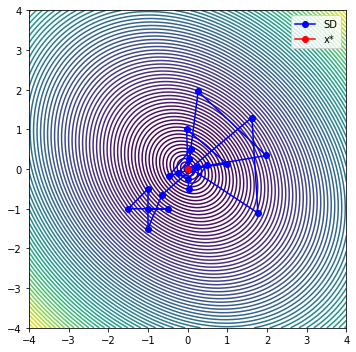


iter evals            fobj        rho        |g|     dmodel         tr  max|l(x)|
0    6      2.72130334e+00  8.869e-01  8.000e+00  3.697e+00  5.000e-01  1.000e+00
1    7      1.81945129e-01  8.569e-01  3.356e+00  2.963e+00  1.000e+00  1.000e+00
2    10    -4.04806453e-01  6.176e-01  1.917e+00  9.501e-01  2.000e+00  3.774e+01
3    11    -4.42528576e-01  2.298e+00  6.541e-01  1.642e-02  2.000e+00  3.774e+01
4    13    -4.42528576e-01 -1.095e-01  4.997e-01  3.200e+00  2.000e+00  1.065e+02
5    17    -4.42528576e-01 -5.409e-02  2.560e-01  2.631e-01  5.000e-01  1.065e+02
6    22    -4.89030270e-01  1.048e+00  5.896e-01  4.438e-02  1.250e-01  1.032e+00
7    23    -4.89030270e-01 -2.132e-01  2.906e-01  4.030e-02  2.500e-01  1.032e+00
8    27    -4.97919722e-01  9.562e-01  2.509e-01  9.297e-03  6.250e-02  4.609e+00
9    28    -4.99680749e-01  5.864e-01  7.024e-02  3.003e-03  1.250e-01  4.609e+00

iter evals            fobj        rho        |g|     dmodel         tr  max|l(x)|
10   30    -4.

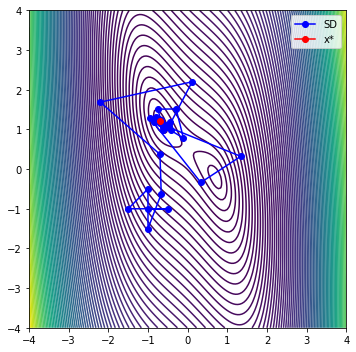


iter evals            fobj        rho        |g|     dmodel         tr  max|l(x)|
0    6      5.00209836e-01  5.831e-01  3.000e+00  8.571e-01  5.000e-01  1.000e+00
1    7      5.00209836e-01 -4.362e-01  9.759e-01  6.889e-02  5.000e-01  1.000e+00
2    11     5.00209836e-01 -1.161e-01  5.813e-02  8.091e-04  1.250e-01  1.284e+00
3    15     5.00010507e-01  1.064e+00  3.012e-02  1.873e-04  3.125e-02  1.284e+00
4    17     5.00009370e-01  6.041e+00  1.219e-03  1.882e-07  6.250e-02  8.613e+00
5    18     5.00006148e-01  2.602e+00  3.431e-03  1.239e-06  1.250e-01  8.613e+00
6    23     5.00006148e-01 -9.891e-01  5.734e-03  2.339e-03  2.500e-01  5.836e+04
7    27     5.00001867e-01  2.908e-01  1.063e-02  1.472e-05  6.250e-02  5.836e+04
8    29     5.00000810e-01  2.432e+00  3.137e-03  4.344e-07  6.250e-02  4.638e+01
9    30     5.00000810e-01 -1.398e+00  5.705e-03  5.896e-06  1.250e-01  4.638e+01


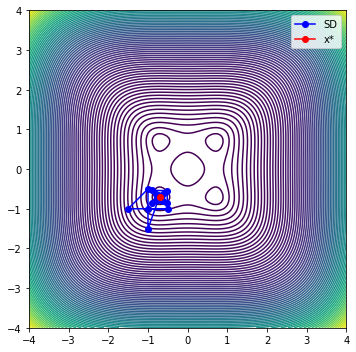


iter evals            fobj        rho        |g|     dmodel         tr  max|l(x)|
0    6      1.16164453e+02  8.336e-01  9.040e+02  3.453e+02  5.000e-01  1.000e+00
1    7      1.00111989e+01  5.254e-01  1.984e+02  2.021e+02  1.000e+00  1.000e+00
2    9      5.63252575e+00  7.679e-02  7.111e+01  5.702e+01  1.000e+00  1.355e+01
3    14     6.90248018e+00  1.593e-01  1.069e+02  1.951e+01  2.500e-01  1.355e+01
4    19     5.19131922e+00  1.007e+00  8.601e+01  4.788e+00  6.250e-02  1.035e+00
5    20     2.89362237e+00  1.155e+00  4.530e+01  1.989e+00  1.250e-01  1.035e+00
6    23     2.89362237e+00 -1.191e+00  4.464e+00  3.567e-01  2.500e-01  7.914e+01
7    28     2.71813578e+00  1.170e+00  8.467e+00  1.499e-01  6.250e-02  7.914e+01
8    30     2.47585312e+00  4.199e-01  2.409e+00  5.771e-01  1.250e-01  1.744e+01
9    31     2.21166464e+00  2.310e+00  2.498e+00  1.144e-01  1.250e-01  1.744e+01

iter evals            fobj        rho        |g|     dmodel         tr  max|l(x)|
10   33     2.

<ipython-input-1-a10ff9ec3f1c>:153: LinAlgWarning: Ill-conditioned matrix (rcond=3.09692e-17): result may not be accurate.
  coef = linalg.solve(self.W, self.d)
<ipython-input-1-a10ff9ec3f1c>:337: LinAlgWarning: Ill-conditioned matrix (rcond=3.09692e-17): result may not be accurate.
  coef = linalg.solve(self.W, rhs)
<ipython-input-1-a10ff9ec3f1c>:153: LinAlgWarning: Ill-conditioned matrix (rcond=3.24362e-17): result may not be accurate.
  coef = linalg.solve(self.W, self.d)
<ipython-input-1-a10ff9ec3f1c>:337: LinAlgWarning: Ill-conditioned matrix (rcond=3.24362e-17): result may not be accurate.
  coef = linalg.solve(self.W, rhs)
<ipython-input-1-a10ff9ec3f1c>:153: LinAlgWarning: Ill-conditioned matrix (rcond=8.3527e-18): result may not be accurate.
  coef = linalg.solve(self.W, self.d)
<ipython-input-1-a10ff9ec3f1c>:337: LinAlgWarning: Ill-conditioned matrix (rcond=8.3527e-18): result may not be accurate.
  coef = linalg.solve(self.W, rhs)
<ipython-input-1-a10ff9ec3f1c>:153: LinAlgWar

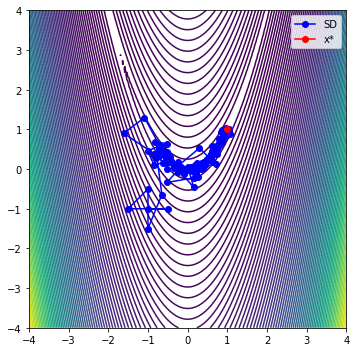


iter evals            fobj        rho        |g|     dmodel         tr  max|l(x)|
0    6     -5.04141221e+00  1.009e+00  2.207e+01  1.131e+01  5.000e-01  1.000e+00
1    7     -1.76857425e+01  5.379e-01  1.613e+01  2.351e+01  1.000e+00  1.000e+00
2    9     -1.89238728e+01  1.496e-01  8.106e+00  8.278e+00  1.000e+00  1.299e+01
3    14    -2.05018448e+01  1.074e+00  1.280e+01  2.622e+00  2.500e-01  1.299e+01
4    16    -2.16441768e+01  3.598e-01  9.290e+00  3.175e+00  5.000e-01  1.164e+01
5    17    -2.21209982e+01  1.563e+00  3.784e+00  3.051e-01  5.000e-01  1.164e+01
6    20    -2.21209982e+01 -1.861e+00  6.594e-01  1.833e-01  1.000e+00  2.017e+01
7    24    -2.21429194e+01  1.024e+00  1.281e+00  2.140e-02  2.500e-01  2.017e+01
8    26    -2.21429194e+01 -1.435e+00  1.455e-02  2.746e-03  5.000e-01  1.243e+02
9    30    -2.21429194e+01 -6.537e-01  1.228e-01  2.913e-04  1.250e-01  1.243e+02

iter evals            fobj        rho        |g|     dmodel         tr  max|l(x)|
10   35    -2.

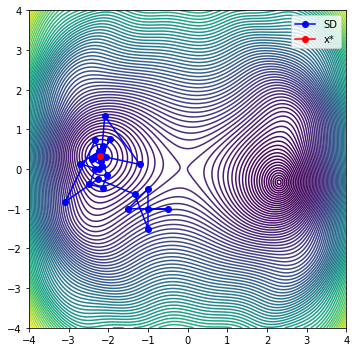

In [1]:
import numpy as np
import scipy.linalg as linalg
import matplotlib.pyplot as plt

class DFOpt:
    def __init__(self, n, objfunc, A=None, b=None, lb=None, ub=None):
        """
        Initialize the data for the derivative-free optimizer
        """

        # Store the number of design variables in the problem
        self.n = n

        # Set the objective function pointer
        self.objfunc = objfunc

        # Compute the max number of interpolation points
        self.m = 2*n + 1

        # The trust region radius
        self.tr = 1.0
        self.tr_max = 2.0
        self.eta = 0.25
        self.max_lambda = 100.0
        self.abs_opt_tol = 1e-3

        # Set up the equality constraints
        if A is not None and b is not None:
            self.b = np.array(b)
            self.A = np.array(A)
            self.multipliers = np.zeros(len(self.b))
            self.penalty = 20.0
        else:
            self.b = None
            self.A = None
            self.multipliers = None
            self.penalty = 0.0

        # Set which version of the trust region constraint to use
        self.use_infty_tr = False
        if lb is not None and ub is not None:
            self.use_infty_tr = True
            self.lb = np.array(lb)
            self.ub = np.array(ub)

        # Flag to determine whether to use the model improvement
        # algorithm after failure of the trust region method
        self.use_model_improvement = True

        # Keep track of the number of function evaluations
        self.fevals = 0

        # The maximum number of iterations
        self.max_major_iterations = 2000

        # Draw the trust region on each iteration - should only
        # be used for 2D problems and when debugging
        self.plot_trust_region_iteration = False

        # Set up the interpolation points
        self.Y = np.zeros((self.n, self.m))
        self.S = np.zeros((self.n, self.m))

        # The vector of function values
        self.fy = np.zeros(self.m)

        # The W matrix and the right-hand-side
        self.d = np.zeros(self.m + self.n + 1)
        self.W = np.zeros((self.m + self.n + 1,
                           self.m + self.n + 1))

        # The quadratic model coefficients
        self.B = np.zeros((self.n, self.n))
        self.g = np.zeros(self.n)
        self.c = 0.0

        return

    def init_model(self, x0, delta):
        """
        Initialize the model parameters at the starting point.

        This uses a finite-difference stencil about the initial point
        to create initial gradient and Hessian information.

        Delta is a parameter which should be not too big but not too
        small - i.e. don't think of it as a finite-difference
        interval.
        """

        # Evaluate the objective at f(x0)
        self.Y[:, 0] = x0
        self.fy[0] = self.objfunc(self.Y[:, 0])

        for j in range(self.n):
            # Evaluate the objective at f(x0 + delta*ej)
            self.Y[:, 2*j+1] = x0
            self.Y[j, 2*j+1] += delta
            self.fy[2*j+1] = self.objfunc(self.Y[:, 2*j+1])

            # Evaluate the objective at f(x0 - delta*ej)
            self.Y[:, 2*(j+1)] = x0
            self.Y[j, 2*(j+1)] -= delta
            self.fy[2*(j+1)] = self.objfunc(self.Y[:, 2*(j+1)])

        # Compute an approximate model about the initial point
        self.c = self.fy[0]
        for j in range(self.n):
            self.g[j] = (self.fy[2*j+1] - self.fy[2*(j+1)])/delta
            self.B[j, j] = (self.fy[2*j+1] - 2*self.fy[0] +
                            self.fy[2*(j+1)])/delta**2

        # Add up the number of function evaluations
        self.fevals += 2*self.n + 1

        return

    def update_model(self):
        """
        Given the new point, compute the least-Frobenius norm update
        """

        # Compute the new components of thee matrix since
        # the points in Y may have changed order
        for j in range(self.m):
            self.S[:, j] = self.Y[:, j] - self.Y[:, 0]

        # Compute S^{T}*S
        A = 0.5*(np.dot(self.S.T, self.S))**2

        # Set the components of the W matrix
        self.W[:] = 0.0
        self.W[:self.m, :self.m] = A

        # Evaluate the inner product sj^{T}*B*sj for j = 1,...,m
        sbs = np.zeros(self.m)
        for j in range(self.m):
            sbs[j] = np.dot(self.S[:, j], np.dot(self.B, self.S[:, j]))

        # Compute dj = f(yj) - mk(yj)
        self.d[:self.m] = (self.fy -
                           (self.c + np.dot(self.S.T, self.g) + 0.5*sbs))

        # Set the unity components
        self.W[self.m, :self.m] = 1.0
        self.W[:self.m, self.m] = 1.0

        # Set the S components
        self.W[:self.m, self.m+1:] = self.S.T
        self.W[self.m+1:, :self.m] = self.S

        # Solve for the update
        coef = linalg.solve(self.W, self.d)

        # Apply the update to the quadratic model
        self.c += coef[self.m]
        self.g += coef[self.m+1:]

        for j in range(self.m):
            self.B += coef[j]*np.outer(self.S[:, j],
                                       self.S[:, j])

        return

    def trust_region_l2(self, g, B, tr, max_iterations=10,
                        tol=1e-6):
        """
        Solve (exactly) the possibly indefinite problem of minimizing
        the function over the domain of interest
        """

        # Compute the eigenvalues of the matrix B
        lamb, Q = linalg.eigh(B)

        # Compute the least value of h allowed
        h = max(-lamb[0], 0.0) + 1e-3

        # Now, iterate until convergence using Newton's method
        for i in range(max_iterations):
            A = B + h*np.eye(B.shape[0])

            # Compute the cholesky factorization
            try:
                U = linalg.cholesky(A)
            except:
                U = linalg.cholesky(A)

            # Compute U^{T}*U*p = -g
            p = linalg.solve_triangular(U, g, trans='T')
            p = -linalg.solve_triangular(U, p, trans='N')

            # Compute the norm of the matrices
            pnrm = linalg.norm(p)

            if np.fabs((pnrm - tr)/tr) <= tol:
                return p

            # Compute U^{T}*q = p
            q = linalg.solve_triangular(U, p, trans='T')
            qnrm = linalg.norm(q)

            # Print the trust region step
            if pnrm == 0.0:
                return p

            dh = ((pnrm - tr)/tr)*(pnrm/qnrm)**2

            if dh > 0.0:
                h += dh
            else:
                return p

        return p

    def trust_region_linfty(self, g, B, lb, ub):
        """
        Approximately solve the quadratic trust-region sub-problem
        using a gradient projection method.

        This method utilizes the piecewise linear path:

        .                     { lb       if x - t*g =< lb
        xp(x - t*g, lb, ub) = { x - t*g  if x - t*g in [lb, ub]
        .                     { ub       if x - t*g >= ub

        The computation proceeds in three steps:

        1. Determine the generalized Cauchy point using the gradient
        projection method along the steepest descent path

        2. Use the active set of constraints and solve approximately
        the trust region problem

        3. Project the final point back into the feasible region
        """

        # Determine the break-point values
        t = np.zeros(self.n)
        for i in range(self.n):
            if g[i] < 0.0:
                t[i] = -ub[i]/g[i]
            elif g[i] > 0.0:
                t[i] = -lb[i]/g[i]
            else:
                t[i] = 1e20

        # Sort the breakpoints
        tsorted = np.sort(t)

        # Initialize the x/p arrays
        x = np.zeros(self.n)
        p = -np.array(g)

        t0 = 0.0
        for k in range(self.n):
            # Update the direction p
            for i in range(self.n):
                if t[i] <= t0:
                    p[i] = 0.0

            # Determine the direction along which we're headed
            f1 = np.dot(g, p) + np.dot(x, np.dot(B, p))
            f2 = np.dot(p, np.dot(B, p))

            # Determine what we should do:
            if f1 > 0.0 or f2 == 0.0:
                # The slope is increasing along this segment
                break

            dt = -f1/f2
            if t0 + dt <= tsorted[k]:
                x += dt*p
                break
            else:
                x += (tsorted[k] - t0)*p

            t0 = tsorted[k]

        # # Compute the reduced Hessian matrix
        # Z = np.eye(self.n)[:, inactive]

        # # Compute the reduced Hessian
        # Br = np.dot(Z.T, np.dot(B, Z))

        # # Solve for the inactive gradient components
        # x[inactive] = -linalg.solve(Br, g[inactive])

        # # Move the solution back onto its bounds if they are violated
        # for i in range(self.n):
        #     x[i] = max(x[i], lb[i])
        #     x[i] = min(x[i], ub[i])

        return x

    def discard_far_points(self, discard=1.5,
                           tr=1.0, max_lambda=10.0):
        """
        Try to improve the Lambda-poised constant by discarding points
        that are far from the center of the current interpolation.

        This algorithm discards points that are further away than
        'discard' and computes new points by maximizing the absolute
        value of the associated Lagrange polynomial.

        if ||yj - y1|| >= discard:
        .    yj^{+} = max_{||x - y1|| < tr} |lj(x)|
        .    Y = {Y \ yj} U yj^{+}

        Here lj(x) is the corresponding Lagrange polynomial.

        input:
        discard:    the discard radius
        tr:         the trust region radius
        max_lambda: the maximum allowable lambda-poised constant
        """

        while True:
            # Compute the point that is the furthest away from
            # the center point y1 = Y[:, 0]
            jdis = 0
            max_dist = 0.0
            for j in range(1, self.m):
                dist = linalg.norm(self.Y[:, j] - self.Y[:, 0])
                if dist > max_dist:
                    jdis = j
                    max_dist = dist

            # If the maximum distancce is less than the discard
            # distance, then quit
            if max_dist < discard:
                return

            # Now, compute the new Lagrange function within the new
            # radius
            rhs = np.zeros(self.m + self.n + 1)
            rhs[jdis] = 1.0
            coef = linalg.solve(self.W, rhs)

            # Compute the specific Lagrange function
            cj = coef[self.m]
            gj = coef[self.m+1:]

            # Compute the second order term for the Lagrange polynomial
            Bj = np.zeros((self.n, self.n))
            for n in range(self.m):
                Bj += coef[n]*np.outer(self.S[:, n],
                                       self.S[:, n])
            # Maximize the lagrange polynomial
            ppos = self.trust_region_l2(gj, Bj, tr)
            lpos = np.fabs(cj + np.dot(gj, ppos) +
                           0.5*np.dot(ppos, np.dot(Bj, ppos)))

            # Minimize the lagrange polynomial
            pneg = self.trust_region_l2(-gj, -Bj, tr)
            lneg = np.fabs(cj + np.dot(gj, pneg) +
                           0.5*np.dot(pneg, np.dot(Bj, pneg)))

            # Select which point to discard
            if lpos >= lneg:
                self.Y[:, jdis] = self.Y[:, 0] + ppos
            else:
                self.Y[:, jdis] = self.Y[:, 0] + pneg

            # Evaluate the objective at the new point
            self.fy[jdis] = self.objfunc(self.Y[:, jdis])
            self.fevals += 1

            # Update the least-Frobenius norm model
            self.update_model()

        return

    def compute_lambda_poised(self, tr=1.0, jstart=0):
        """
        Compute the maximum absolute value of the Lagrange polyomials
        within the given trust region and return the max value, the
        index of the Lagrange polynomial and the location of the
        maximum.

        input:
        tr:            the trust region radius

        output:
        max_lagrange:  the max absolute value of the Lagrange polyomial
        jmax:          the max index
        ymax:          the location of the max within the trust region
        """

        jmax = 1
        ymax = None
        max_lagrange = 0.0

        for j in range(jstart, self.m):
            # Compute the components of the Lagrange polynomials
            rhs = np.zeros(self.m + self.n + 1)
            rhs[j] = 1.0
            coef = linalg.solve(self.W, rhs)

            # Compute the specific Lagrange function
            cj = coef[self.m]
            gj = coef[self.m+1:]

            # Compute the coefficients
            Bj = np.zeros((self.n, self.n))
            for n in range(self.m):
                Bj += coef[n]*np.outer(self.S[:, n],
                                       self.S[:, n])

            # Maximize the lagrange interpolant
            ppos = self.trust_region_l2(gj, Bj, tr)
            lpos = np.fabs(cj + np.dot(gj, ppos) +
                           0.5*np.dot(ppos, np.dot(Bj, ppos)))

            # Minimize the lagrange interpolant
            pneg = self.trust_region_l2(-gj, -Bj, tr)
            lneg = np.fabs(cj + np.dot(gj, pneg) +
                           0.5*np.dot(pneg, np.dot(Bj, pneg)))

            # Keep track of the maximum value seen thus far
            if max(lpos, lneg) > max_lagrange:
                max_lagrange = max(lpos, lneg)
                jmax = j

                if lpos >= lneg:
                    ymax = self.Y[:, 0] + ppos
                else:
                    ymax = self.Y[:, 0] + pneg

        return max_lagrange, jmax, ymax

    def model_improvement(self, tr=1.0, max_lambda=10.0):
        """
        Ensure that the set of interpolation points is well-poised for
        interpolation over the trust region. This guarantees that our
        model is fully linear/fully quadratic within the the trust
        region given. This is the interpolation improvement algorithm
        given by Conn et al. in an Introduction to Derivative Free
        Optimization.

        input:
        tr:         the trust region radius
        max_lambda: the maximum allowable lambda-poised constant
        """

        # Next, make sure that the Y-set is well-poised for
        # interpolation
        for i in range(self.m):
            max_lagrange, jmax, ymax =\
                self.compute_lambda_poised(tr=tr, jstart=1)

            # Check if the maximum lambda-poised constant is exceeded
            if max_lagrange > max_lambda:
                fobj = self.objfunc(ymax)
                self.fevals += 1

                # If we're replacing the base point, then we have
                # to re-adjust the least-Frobenius norm model
                if jmax == 0:
                    # Calculate the displacement to the new point
                    p = ymax - self.Y[:, 0]

                    # Re-center the model about the new point
                    self.c += np.dot(self.g, p) + 0.5*np.dot(p, np.dot(self.B, p))
                    self.g[:] += np.dot(self.B, p)

                # Set the new interpolation points
                self.Y[:, jmax] = ymax
                self.fy[jmax] = fobj
            else:
                return

            # Update the model using the least-Frobenius norm
            # update
            self.update_model()

        return

    def plot_trust_region(self, x, ntr=2, n=75):
        """
        Draw the original problem and the trust region problem.

        Warning: This uses a lot of function evaluations and is
        primarily intended for debugging/visualization.
        """

        if plt is None:
            return

        xmin = self.Y[0, 0] - ntr*self.tr
        xmax = self.Y[0, 0] + ntr*self.tr
        ymin = self.Y[1, 0] - ntr*self.tr
        ymax = self.Y[1, 0] + ntr*self.tr

        # Create the range of x/y values to plot
        x1 = np.linspace(xmin, xmax, n)
        y1 = np.linspace(ymin, ymax, n)
        R = np.zeros((n, n))
        r = np.zeros((n, n))

        # Create the contour plot for the real function
        for j in range(n):
            for i in range(n):
                R[j, i] = self.objfunc([x1[i], y1[j]])

        # Set the levels for the real function
        Rlevels = np.min(R) + np.linspace(0, 1.0, 25)**2*(np.max(R) - np.min(R))

        # Create the contours for the trust region subproblem
        for j in range(n):
            for i in range(n):
                p = np.array([x1[i] - self.Y[0, 0],
                              y1[j] - self.Y[1, 0]])
                r[j, i] = (self.c + np.dot(self.g, p) +
                           0.5*np.dot(p, np.dot(self.B, p)))

        # Create the plot
        fig = plt.figure(facecolor='w')
        plt.contour(x1, y1, r, Rlevels)
        plt.contour(x1, y1, R, Rlevels)

        # Plot the interpolation points
        for j in range(1, self.m):
            plt.plot([self.Y[0, 0], self.Y[0, j]],
                     [self.Y[1, 0], self.Y[1, j]],
                     '-go', label=None)

        # Plot the new point itself
        plt.plot(x[0], x[1], 'ro')

        # Plot the trust region
        if self.use_infty_tr:
            x0 = self.Y[0, 0]
            y0 = self.Y[1, 0]
            xt = [x0 - self.tr, x0 + self.tr, x0 + self.tr,
                  x0 - self.tr, x0 - self.tr]
            yt = [y0 - self.tr, y0 - self.tr, y0 + self.tr,
                  y0 + self.tr, y0 - self.tr]

            for i in range(5):
                if xt[i] < self.lb[0]:
                    xt[i] = self.lb[0]
                elif xt[i] > self.ub[0]:
                    xt[i] = self.ub[0]
                if yt[i] < self.lb[1]:
                    yt[i] = self.lb[1]
                elif yt[i] > self.ub[1]:
                    yt[i] = self.ub[1]
            plt.plot(xt, yt, '-r', linewidth=2)
        else:
            cs = np.cos(np.linspace(0, 2*np.pi, 100))
            ss = np.sin(np.linspace(0, 2*np.pi, 100))
            plt.plot(self.Y[0, 0] + self.tr*cs,
                     self.Y[1, 0] + self.tr*ss, '-r', linewidth=2)

        # Set the axis to be centered around the interpolation points
        plt.axis([xmin, xmax, ymin, ymax])
        plt.show()

        return

    def optimize(self, x, delta=0.1):
        """
        Perform the derivative-free optimization.

        This algorithm, as described above, uses a least-Frobenius
        norm updating scheme to construct a quadratic model of the
        objective function at each iteration. A simple gradient
        criteria is used in conjunction with a test to ensure that the
        interpolation is sufficiently accurate. This test is
        implemented as a check on the maximum absolute value of the
        Lagrange polynomial within the trust region.
        """

        # Ensure that the design point is a numpy array
        x = np.array(x)

        # Initialize the quadratic model about the given point
        self.init_model(x, delta)

        # Update the model
        self.update_model()

        max_lagrange = 1.0

        for k in range(self.max_major_iterations):
            # Set the base point about which we'll construct the model
            x0 = self.Y[:, 0]

            # Add the term from the augmented Lagrangian (if needed)
            if self.A is not None and self.b is not None:
                con = np.dot(self.A, x0) - self.b
                cval = self.penalty*con - self.multipliers
                g = self.g + np.dot(self.A.T, cval)
            else:
                g = self.g

            # If we have bound constraints, zero the gradient components
            # associated with the bound constraints
            gnrm = 0.0
            if self.use_infty_tr:
                for i in range(len(x0)):
                    if self.lb[i] < x0[i] and x0[i] < self.ub[i]:
                        gnrm += g[i]**2
                gnrm = np.sqrt(gnrm)
            else:
                # Compute the gradient norm
                gnrm = np.max(np.fabs(g))

            # If the approximate gradient is zero, check if the model
            # is good enough, then make a decision about exiting -
            # without this check we could exit with bad gradient
            # information
            if gnrm < self.abs_opt_tol:
                con_flag = True
                if self.A is not None and self.b is not None:
                    con = np.dot(self.A, x0) - self.b
                    if np.sqrt(np.dot(con, con)) > self.abs_opt_tol:
                        self.multipliers -= self.penalty*con
                    else:
                        conf_flag = False

                if con_flag:
                    max_lagrange, jmax, ymax =\
                        self.compute_lambda_poised(tr=self.tr)

                    # Check that the set is actually lambda poised
                    if max_lagrange < self.max_lambda:
                        break
                    else:
                        # Try the model improvement algorithm
                        self.model_improvement(tr=self.tr,
                                               max_lambda=self.max_lambda)

                        # Recompute the gradient
                        if self.A is not None and self.b is not None:
                            con = np.dot(self.A, x0) - self.b
                            cval = self.penalty*con - self.multipliers
                            g = self.g + np.dot(self.A.T, cval)
                        else:
                            g = self.g

                        # Recompute the gradient and try the gradient
                        # test again
                        gnrm = 0.0
                        if self.use_infty_tr:
                            for i in range(len(x0)):
                                if self.lb[i] < x0[i] and x0[i] < self.ub[i]:
                                    gnrm += g[i]**2
                            gnrm = np.sqrt(gnrm)
                        else:
                            # Compute the gradient norm
                            gnrm = np.max(np.fabs(g))

                        # Check if the gradient has converged
                        if gnrm < self.abs_opt_tol:
                            break

            # Compute the lambda-poised constant - this is just used
            # for printing/monitoring purposes, so it could be removed
            if k % self.n == 0:
                max_lagrange, jmax, ymax =\
                    self.compute_lambda_poised(tr=self.tr)

                if max_lagrange > self.max_lambda:
                    # Perform the model improvement steps if required
                    self.model_improvement(tr=self.tr,
                                           max_lambda=self.max_lambda)

            # Set the old value of the objective function
            x0 = self.Y[:,0]
            fobj_old = self.fy[0]

            # Set up the model problem. If this is unconstrained, use only the
            # least-Frobenius norm model of the objective function. Otherwise,
            # add the augmented Lagrangian terms from the constraints.
            if self.A is not None and self.b is not None:
                # Compute the constraint violation
                con = np.dot(self.A, x0) - self.b
                cval = self.penalty*con - self.multipliers

                # Add the terms from the augmented Lagrangian
                fobj_old += 0.5*self.penalty*np.dot(con, con)
                fobj_old -= np.dot(self.multipliers, con)

                # Add the augmented Lagrangian terms to the gradient/hessian
                g = self.g + np.dot(self.A.T, cval)
                B = self.B + self.penalty*np.dot(self.A.T, self.A)
            else:
                g = self.g
                B = self.B

            # Compute the l2 trust region solution
            if self.use_infty_tr:
                lb = np.zeros(self.lb.shape)
                ub = np.zeros(self.ub.shape)
                for i in range(len(self.lb)):
                    lb[i] = -self.tr
                    ub[i] = self.tr
                    if x0[i] - self.tr <= self.lb[i]:
                        lb[i] = self.lb[i] - x0[i]
                    if x0[i] + self.tr >= self.ub[i]:
                        ub[i] = self.ub[i] - x0[i]

                # Solve the l-infinity trust region problem to find
                # the next step
                p = self.trust_region_linfty(g, B, lb, ub)
            else:
                p = self.trust_region_l2(g, B, self.tr)

            # Compute the new point
            x = x0 + p

            # Compute the model reduction
            mreduce = -np.dot(g, p) - 0.5*np.dot(p, np.dot(B, p))

            # Evaluate the objective at the new point
            fval = self.objfunc(x)
            self.fevals += 1
            fobj = 1.0*fval

            # Add the terms from the augmented Lagrangian
            if self.A is not None and self.b is not None:
                con = np.dot(self.A, x) - self.b
                fobj += 0.5*self.penalty*np.dot(con, con)
                fobj -= np.dot(self.multipliers, con)

            # Compute the ratio of the actual reduction to the
            # predicted reduction
            rho = (fobj_old - fobj)/mreduce

            if k % 10 == 0:
                print('\n%4s %5s %15s %10s %10s %10s %10s %10s'%(
                    'iter', 'evals', 'fobj', 'rho', '|g|',
                    'dmodel', 'tr', 'max|l(x)|'))

            # Print the result to the screen
            print('%-4d %-5d %15.8e %10.3e %10.3e %10.3e %10.3e %10.3e'%(
                k, self.fevals, min(fobj, fobj_old), rho,
                gnrm, mreduce, self.tr, max_lagrange))

            # Draw the trust region step if required
            if self.plot_trust_region_iteration:
                self.plot_trust_region(x)

            # Update the trust region size
            if rho < 0.25:
                self.tr *= 0.25
            elif rho > 0.75:
                self.tr = min(self.tr_max, 2*self.tr)

            # If this was a successful step, update and re-center
            # about the new point
            if rho > self.eta:
                # Discard the point that is furthest from
                # the new base point
                jdis = 0
                max_dist = 0.0
                for j in range(self.m):
                    dist = linalg.norm(self.Y[:, j] - x)
                    if dist > max_dist:
                        max_dist = dist
                        jdis = j

                # Compute the step between the new center and the old
                # center - store this in the step p
                p = x - self.Y[:, 0]

                if jdis != 0:
                    # Copy the old center point to the discarded index
                    self.Y[:, jdis] = self.Y[:, 0]
                    self.fy[jdis] = self.fy[0]

                # Copy the new point to the old center point
                self.Y[:, 0] = x[:]
                self.fy[0] = fval

                # Re-center the model about the new point
                self.c += (np.dot(self.g, p) +
                           0.5*np.dot(p, np.dot(self.B, p)))
                self.g[:] += np.dot(self.B, p)

                # Use the least-Frobenius norm update scheme
                self.update_model()
            else:
                # First, add the point that we just computed that has
                # been rejected by removing the point that is furthest
                # away from the center point.
                jdis = 0
                max_dist = 0.0
                for j in range(1, self.m):
                    dist = linalg.norm(self.Y[:, j] - self.Y[:, 0])
                    if dist > max_dist:
                        jdis = j
                        max_dist = dist

                self.fy[jdis] = fval
                self.Y[:, jdis] = x

                # Update the least-Frobenius norm update
                self.update_model()

                # Note: We must discard the points outside of the
                # trust region AND execute a model improvement
                # algorithm to ensure that the interpolation set is
                # poised for interpolation - otherwise we will just
                # have a set that is poised, but not within the trust
                # region.

                # Discard points from the interpolation set that
                # are too far away from the solution
                r = 1.5
                self.discard_far_points(discard=r*self.tr, tr=self.tr,
                                        max_lambda=self.max_lambda)

                if self.use_model_improvement:
                    # Perform the model improvement steps if required
                    self.model_improvement(tr=self.tr,
                                           max_lambda=self.max_lambda)

        return x

class Problem1:
    def __init__(self):
        self.x_hist = []
        return

    def obj_func(self, x):
        self.x_hist.append(np.array(x))
        return 2*x[0]**2 + 2*x[1]**2 + x[0]*x[1]

    def gobj_func(self, x):
        g = np.zeros(2)
        g[0] = 4*x[0] + x[1]
        g[1] = 4*x[1] + x[0]
        return g

class Problem2:
    def __init__(self):
        self.x_hist = []
        return

    def obj_func(self, x):
        self.x_hist.append(np.array(x))
        return x[0]**4 + x[1]**2 + 2*x[0]*x[1] - x[0] - x[1]

    def gobj_func(self, x):
        g = np.zeros(2)
        g[0] = 4*x[0]**3 + 2*x[1] - 1.0
        g[1] = 2*x[1] + 2*x[0] - 1.0
        return g

class Problem3:
    def __init__(self):
        self.x_hist = []
        return

    def obj_func(self, x):
        self.x_hist.append(np.array(x))
        return x[0]**4 + x[1]**4 + 1 - x[0]**2 - x[1]**2

    def gobj_func(self, x):
        g = np.zeros(2)
        g[0] = 4*x[0]**3 - 2*x[0]
        g[1] = 4*x[1]**3 - 2*x[1]
        return g

class Problem4:
    def __init__(self):
        self.x_hist = []
        return

    def obj_func(self, x):
        self.x_hist.append(np.array(x))
        return 100*(x[1]-x[0]**2)**2 + (1-x[0])**2

    def gobj_func(self, x):
        g = np.zeros(2)
        g[0] = 200*(x[1]-x[0]**2)*(-2*x[0]) - 2*(1-x[0])
        g[1] = 200*(x[1]-x[0]**2)
        return g

class Problem5:
    def __init__(self):
        self.x_hist = []
        return

    def obj_func(self, x):
        self.x_hist.append(np.array(x))
        return -10*x[0]**2 + 10*x[1]**2 + 4*np.sin(x[0]*x[1]) - 2*x[0] + x[0]**4

    def gobj_func(self, x):
        g = np.zeros(2)
        g[0] = -20*x[0] + 4*np.cos(x[0]*x[1])*x[1] - 2.0 + 4*x[0]**3
        g[1] =  20*x[1] + 4*np.cos(x[0]*x[1])*x[0]
        return g

def plot_it_all(optimizer, problem, x_start=[-1.0, -1.0]):
    """
    Plot a carpet plot with the search histories for steepest descent,
    conjugate gradient and BFGS from the same starting point.
    """

    # Create the data for the carpet plot
    n = 150
    xlow = -4.0
    xhigh = 4.0
    x1 = np.linspace(xlow, xhigh, n)
    r = np.zeros((n, n))

    for j in range(n):
        for i in range(n):
            r[j, i] = problem.obj_func([x1[i], x1[j]])

    # Run steepest descent
    x0 = np.array(x_start)
    problem.x_hist = []
    x = optimizer.optimize(x0, delta=0.5)

    # print('|c(x)| ', np.sum(x) - 1.0)

    # Assign the contour levels
    levels = np.min(r) + np.linspace(0, 1.0, 75)**2*(np.max(r) - np.min(r))

    # Copy out the steepest descent points
    sd = np.zeros((2, len(problem.x_hist)))
    for i in range(len(problem.x_hist)):
        sd[0, i] = problem.x_hist[i][0]
        sd[1, i] = problem.x_hist[i][1]

    # Now, plot it all on a single plot
    # Start plotting the figure
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.contour(x1, x1, r, levels)
    plt.plot(sd[0, :], sd[1, :], '-bo', label='SD')
    plt.plot(x[0], x[1], '-ro', label='x*')
    ax.set_aspect('equal', 'box')
    fig.tight_layout()
    plt.legend()
    plt.axis([xlow, xhigh, xlow, xhigh])
    plt.show()

# x_start = np.random.uniform(low=-2.0, high=2.0, size=2)

x_start = [-1.0, -1.0]
# np.random.uniform(low=-2.0, high=2.0, size=2)

problems = [Problem1(), Problem2(),
            Problem3(), Problem4(), Problem5()]
# problems = [Problem4()]

for problem in problems:
    # Create the optimizer object
    opt = DFOpt(2, problem.obj_func) #, A=[[1, 1]], b=[1])
    opt.max_lambda = 10.0
    opt.abs_opt_tol = 1e-3
    opt.eta = 0.25
    opt.tr = 0.5
    opt.use_model_improvement = True
    opt.plot_trust_region_iteration = False

    # Plot all the functions
    plot_it_all(opt, problem, x_start)

plt.show()